### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

In [3]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
df

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9
...,...,...,...,...,...
188,Venezuela,333,100,3,7.7
189,Vietnam,111,2,1,2.0
190,Yemen,6,0,0,0.1
191,Zambia,32,19,4,2.5


In [4]:
maggiori_bevitori = df[['country','total_litres_of_pure_alcohol']].sort_values(axis=0, by='total_litres_of_pure_alcohol', ascending=False).head(10)
medie = df[['beer_servings', 'spirit_servings', 'wine_servings']].mean()
round(medie, 2)
df['alcohol_index'] = (df.beer_servings + df.spirit_servings + df.wine_servings)/3
df.head()
df[df['country'] == df.alcohol_index.max()]
df[df.alcohol_index == df.alcohol_index.max()]['country']
df[df.beer_servings > 100][['country','beer_servings']]


,country,beer_servings
3,Andorra,245
4,Angola,217
5,Antigua & Barbuda,102
6,Argentina,193
8,Australia,261
...,...,...
182,United Kingdom,219
184,USA,249
185,Uruguay,115
188,Venezuela,333


In [5]:
import matplotlib.pyplot as plt

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Belarus'),
  Text(1, 0, 'Lithuania'),
  Text(2, 0, 'Andorra'),
  Text(3, 0, 'Grenada'),
  Text(4, 0, 'Czech Republic'),
  Text(5, 0, 'France'),
  Text(6, 0, 'Russian Federation'),
  Text(7, 0, 'Ireland'),
  Text(8, 0, 'Slovakia'),
  Text(9, 0, 'Luxembourg')])

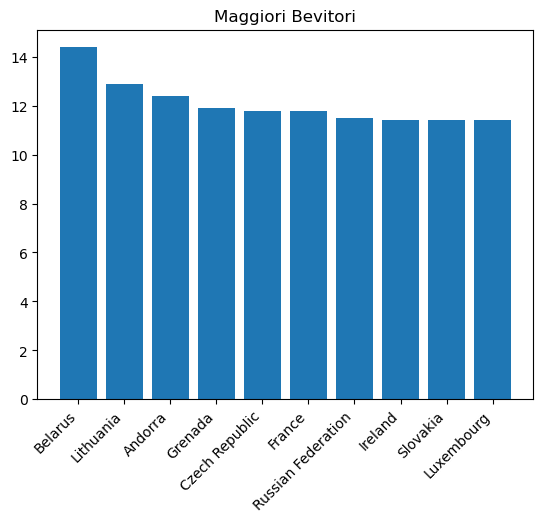

In [9]:
plt.bar(maggiori_bevitori['country'], maggiori_bevitori['total_litres_of_pure_alcohol'])
plt.title('Maggiori Bevitori')
plt.xticks(rotation=45, ha='right')

Text(0.5, 0, ' ')

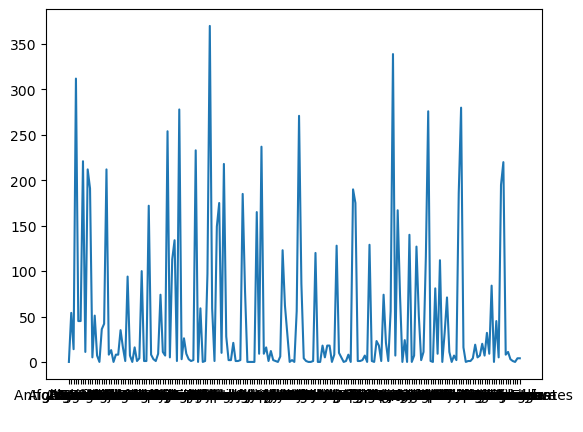

In [24]:
#Crea un line plot con wine_servings ordinato per paese (usa sort_values)
vino = df[['country', 'wine_servings']].sort_values(axis=0, by='country')
plt.plot(vino['country'], vino['wine_servings'])

### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

In [43]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [103]:
df.groupby('job_country')['salary_year_avg'].mean()
df.groupby('job_country')['job_country'].count()
stipendi_minmax = df.groupby('job_country')['salary_year_avg'].agg(['min', 'max'])
stipendi_minmax[stipendi_minmax['max'] == stipendi_minmax['max'].max()]
stipendi_minmax[stipendi_minmax['min'] == stipendi_minmax['min'].min()]

,min,max
job_country,,
Brazil,15000.0,224000.0


Text(0, 0.5, 'Lavoro')

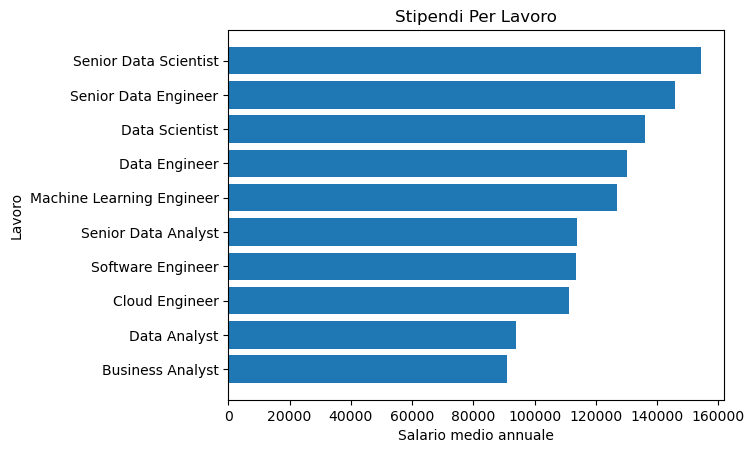

In [66]:
df_pulito = df.dropna(subset='salary_year_avg')
#df_pulito['salary_year_avg'].head()
#su groupby dropna è di default true, posso non farlo
stipendio_medio_per_lavoro = df_pulito.groupby('job_title_short')['salary_year_avg'].mean().sort_values() #series
plt.barh(stipendio_medio_per_lavoro.index, stipendio_medio_per_lavoro.values)
plt.title('Stipendi Per Lavoro')
plt.xlabel('Salario medio annuale')
plt.ylabel('Lavoro')

In [34]:
#raggruppo per il job country e poi faccio la media per salary
media = df.groupby('job_country')['salary_year_avg'].mean() 
media

job_country
Afghanistan              NaN
Albania         79472.500000
Algeria         44550.000000
Angola                   NaN
Argentina      105212.343750
                   ...      
Venezuela                NaN
Vietnam         90927.236364
Yemen                    NaN
Zambia          90670.000000
Zimbabwe        67056.666667
Name: salary_year_avg, Length: 160, dtype: float64

In [25]:
#prendo la colonna del df e conto i valori con uguali
offerte_lavoro_per_paese = df['job_country'].value_counts()
offerte_lavoro_per_paese


job_country
United States               206292
India                        51088
United Kingdom               40375
France                       39922
Germany                      27694
                             ...  
Northern Mariana Islands         4
Lesotho                          3
Mauritania                       3
Bhutan                           3
Maldives                         2
Name: count, Length: 160, dtype: int64

In [26]:
#alternativa 
numero_offerte_per_paese_alernativo = df.groupby('job_country')['job_country'].count()
numero_offerte_per_paese_alernativo

job_country
Afghanistan      16
Albania         119
Algeria         111
Angola           11
Argentina      8736
               ... 
Venezuela        69
Vietnam        2414
Yemen            10
Zambia          104
Zimbabwe         81
Name: job_country, Length: 160, dtype: int64

In [27]:
numero_offerte_per_paese = df.groupby('job_country')['salary_year_avg'].agg(['min', 'max'])

In [26]:
numero_offerte_per_paese

,min,max
job_country,,
Afghanistan,NaN,NaN
Albania,43200.0,157500.0
Algeria,44100.0,45000.0
Angola,NaN,NaN
Argentina,45000.0,222000.0
...,...,...
Venezuela,NaN,NaN
Vietnam,28000.0,200000.0
Yemen,NaN,NaN


In [ ]:
stipendio_medio_per_job_title = df.groupby('job_title_short')['salary_year_avg'].mean

<bound method GroupBy.mean of <pandas.api.typing.SeriesGroupBy object at 0x372ad7c80>>

### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

In [106]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [188]:
media_giornaliera = round((df.groupby('day')['total_bill'].mean()),2)
#media_giornaliera
df.count #244 osservazioni
df.total_bill.agg(['min', 'max'])
df['conto_per_persona'] = round(df['total_bill']/df['size'], 2)
media_giornaliera[media_giornaliera.values == media_giornaliera.values.max()]


day
Sun    21.41
Name: total_bill, dtype: float64

Text(0.5, 1.0, 'Conto Medio Nei Giorni')

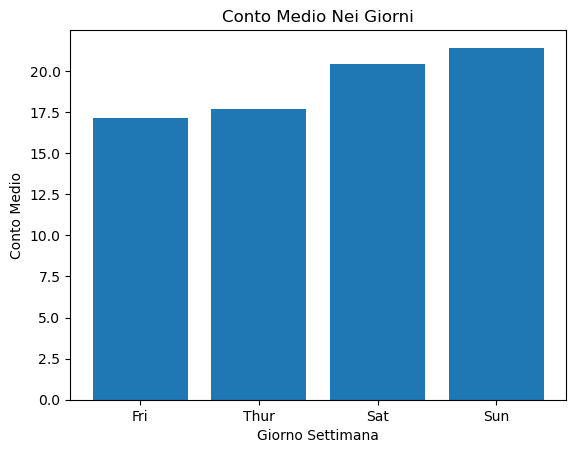

In [189]:
media_giornaliera.sort_values(inplace=True)
plt.bar(media_giornaliera.index, media_giornaliera.values)
plt.xlabel('Giorno Settimana')
plt.ylabel('Conto Medio')
plt.title('Conto Medio Nei Giorni')